# RetentionAI — Phase 2: EDA & Data Cleaning
**Objective:** To clean the raw Telco Churn data and uncover business insights through visual storytelling before feeding it to our machine learning models.

---

### **1. Environment Setup & Data Loading**
We start by loading the dataset generated from our automated extraction pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted")

# Portable path loading
RAW_DATA_PATH = os.path.join('..', 'data', 'raw', 'telco_churn.csv')
df = pd.read_csv(RAW_DATA_PATH)

print(f"✔ Raw Data Loaded. Shape: {df.shape}")
df.head(3)

✔ Raw Data Loaded. Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


### **2. 🧹 Data Cleaning (The Foundation)**
Before visualizing, we must ensure data integrity. During initial checks, `TotalCharges` was found to be a string type due to hidden blank spaces for new customers.

In [2]:
# 1. Convert TotalCharges to numeric (errors='coerce' turns blanks into NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Impute the 11 NaN values with 0 (Since tenure is 0, they haven't paid yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 3. Drop 'customerID' as it is a unique identifier with no predictive power
df.drop('customerID', axis=1, inplace=True)

print("✔ Data Cleaning Complete. No missing values remain.")

✔ Data Cleaning Complete. No missing values remain.


### **3. 📊 Exploratory Data Analysis (Uncovering Patterns)**
Now we analyze the features that drive customer churn.

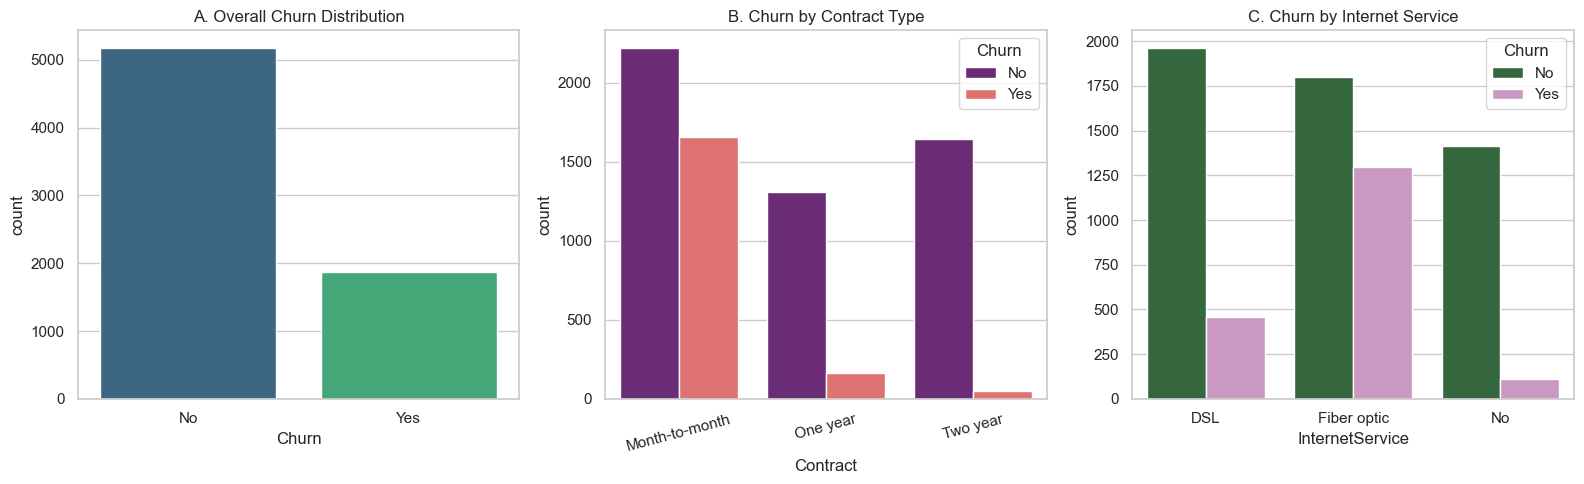

In [6]:
plt.figure(figsize=(16, 5))

# Plot A: Target Variable Imbalance
plt.subplot(1, 3, 1)
sns.countplot(x='Churn', hue = 'Churn', data=df, palette='viridis')
plt.title('A. Overall Churn Distribution')

# Plot B: Contract Type
plt.subplot(1, 3, 2)
sns.countplot(x='Contract', hue='Churn', data=df, palette='magma')
plt.title('B. Churn by Contract Type')
plt.xticks(rotation=15)

# Plot C: Internet Service
plt.subplot(1, 3, 3)
sns.countplot(x='InternetService', hue='Churn', data=df, palette='cubehelix')
plt.title('C. Churn by Internet Service')

plt.tight_layout()
plt.show()

**💡 Key Business Insights from Categorical Data:**
* **Imbalance:** Only ~26% of customers churned. We will need to apply techniques like SMOTE during preprocessing to handle this class imbalance.
* **Contract Risk:** Customers on **Month-to-month** contracts are extremely flight-prone. Securing users into 1-year or 2-year contracts drastically improves retention.
* **Service Issue:** **Fiber optic** users have an unusually high churn rate compared to DSL. This points to a potential product quality or pricing issue.

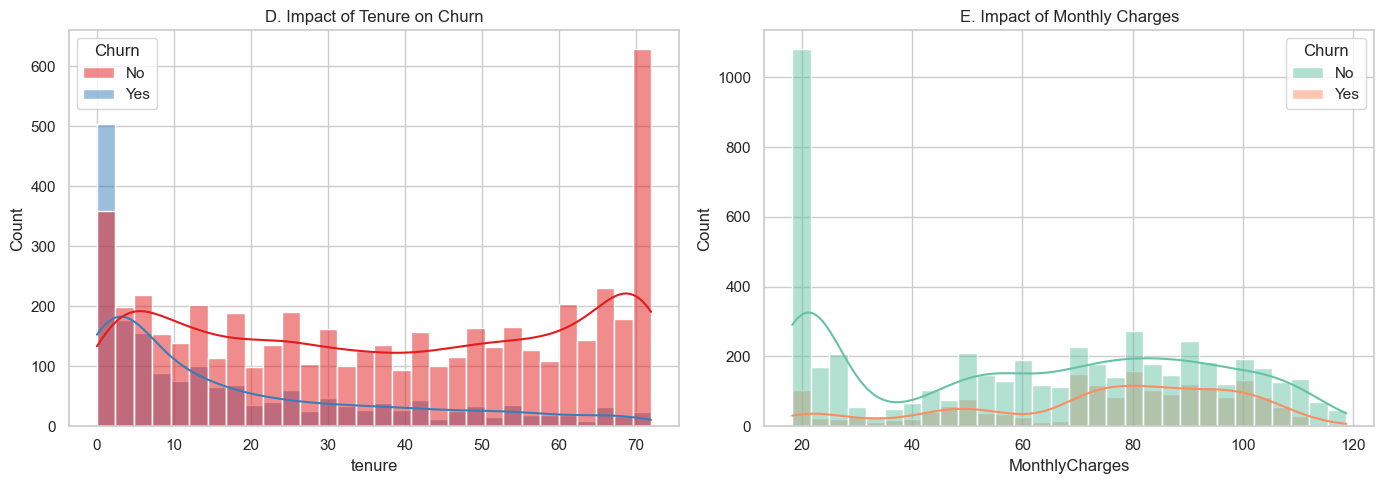

In [4]:
plt.figure(figsize=(14, 5))

# Plot D: Tenure vs Churn
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30, palette='Set1')
plt.title('D. Impact of Tenure on Churn')

# Plot E: Monthly Charges vs Churn
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, bins=30, palette='Set2')
plt.title('E. Impact of Monthly Charges')

plt.tight_layout()
plt.show()

**💡 Key Business Insights from Numerical Data:**
* **The 'Danger Zone':** Most churn happens in the first 0-10 months of `tenure`. If we retain a customer past the first year, they are highly likely to stay.
* **Pricing Sensitivity:** Customers paying higher `MonthlyCharges` (between $70-$100) churn much more frequently than those on cheaper plans.

### **4. 💾 Exporting Cleaned Data**
The dataset is clean and visually analyzed. We now export it for the Preprocessing & Model Training phase.

In [5]:
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

PROCESSED_PATH = os.path.join(PROCESSED_DIR, 'telco_churn_cleaned.csv')
df.to_csv(PROCESSED_PATH, index=False)

print(f"✔ Cleaned Data Successfully Saved to: {PROCESSED_PATH}")

✔ Cleaned Data Successfully Saved to: ..\data\processed\telco_churn_cleaned.csv
